In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List
import numpy as np


from src.data_models.caravanify import Caravanify, CaravanifyConfig


---

In [3]:
def extract_source_basins_for_training(
    ca_groups_path: str, source_clusters_path: str, group_mappings: Dict
) -> Dict:
    """
    Extract source basins corresponding to CA target basins grouped by their major groups.

    Args:
        ca_groups_path: Path to CSV file with CA basin group assignments
        source_clusters_path: Path to CSV file with source basin cluster assignments
        group_mappings: Dictionary defining the mapping between groups and clusters

    Returns:
        Dictionary with training data structure organized by target groups
    """
    # Load the data
    ca_groups = pd.read_csv(ca_groups_path)
    source_clusters = pd.read_csv(source_clusters_path)

    training_data = {}

    # Process each group
    for group_key, group_info in group_mappings.items():
        # Get CA basins for this group
        ca_group_basins = ca_groups[
            ca_groups["major_group"] == group_info["ca_group_label"]
        ]["gauge_id"].tolist()

        # Get source basins for this group by cluster
        source_group_basins = source_clusters[
            source_clusters["cluster"].isin(group_info["clusters"])
        ]["gauge_id"].tolist()

        # Split source basins by country
        country_basins = {
            "CH": [basin for basin in source_group_basins if basin.startswith("CH_")],
            "USA": [basin for basin in source_group_basins if basin.startswith("USA_")],
            "CL": [basin for basin in source_group_basins if basin.startswith("CL_")],
        }

        # Store in training data structure
        training_data[group_key] = {
            "target": ca_group_basins,
            "source": country_basins,
        }

        # Print summary statistics
        print(f"{group_key} - CA target basins: {len(ca_group_basins)}")
        for country, basins in country_basins.items():
            print(f"{group_key} - {country} source basins: {len(basins)}")
        print()

    return training_data


def load_data_for_group(
    group_key: str,
    training_data: Dict,
    ca_config: Dict,
) -> Dict:
    """
    Load all data for a specific group using Caravanify.

    Args:
        group_key: Key of the group to load data for (e.g., 'group1')
        training_data: Dictionary with basin mapping information
        ca_config: Configuration for CA data
        ch_config: Configuration for Switzerland data
        usa_config: Configuration for USA data
        cl_config: Configuration for Chile data

    Returns:
        Dictionary with loaded time series and static data
    """
    print(f"Loading data for {group_key}...")

    # Get relevant basin IDs
    ca_basins = training_data[group_key]["target"]

    # Dictionary to store data from each country
    data = {
        "ca_ts_data": None,
        "ca_static_data": None,
    }

    # Load CA data
    ca_caravan_config = CaravanifyConfig(
        attributes_dir=ca_config["ATTRIBUTE_DIR"],
        timeseries_dir=ca_config["TIMESERIES_DIR"],
        gauge_id_prefix=ca_config["GAUGE_ID_PREFIX"],
        use_hydroatlas_attributes=True,
        use_caravan_attributes=True,
        use_other_attributes=True,
    )

    ca_caravan = Caravanify(ca_caravan_config)
    ca_caravan.load_stations(ca_basins)
    data["ca_ts_data"] = ca_caravan.get_time_series()
    data["ca_static_data"] = ca_caravan.get_static_attributes()

    return data

In [4]:
# Configuration for group mappings
group_mappings = {
    "group1": {
        "name": "Group 1 [3, 5]",
        "clusters": [3, 5],
        "ca_group_label": "Group 1 [3, 5]",
    },
    "group2": {
        "name": "Group 2 [5, 7]",
        "clusters": [5, 7],
        "ca_group_label": "Group 2 [5, 7]",
    },
}


# Path configuration
ca_groups_path = "/Users/cooper/Desktop/CAMELS-CH/classification_results/final_basin_assignments_for_13_clusters.csv"
source_clusters_path = "/Users/cooper/Desktop/CAMELS-CH/clustering_results/cluster_assignments13.csv"

# Country configurations
ca_config = {
    "ATTRIBUTE_DIR": "/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/attributes",
    "TIMESERIES_DIR": "/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/timeseries/csv",
    "GAUGE_ID_PREFIX": "CA",
    "MIN_TRAIN_YEARS": 8,
    "VAL_YEARS": 2,
    "TEST_YEARS": 5,
    "MAX_MISSING_PCT": 15,
}

# Step 1: Extract source basins for training
training_data = extract_source_basins_for_training(
    ca_groups_path=ca_groups_path,
    source_clusters_path=source_clusters_path,
    group_mappings=group_mappings
)

# Step 2: Load data for a specific group
group_key = "group2"  # Choose which group to load

group_data = load_data_for_group(
    group_key=group_key,
    training_data=training_data,
    ca_config=ca_config,
)

# Access the loaded data
print(f"CA time series data shape: {group_data['ca_ts_data'].shape}")
print(f"CA static data shape: {group_data['ca_static_data'].shape}")

group1 - CA target basins: 48
group1 - CH source basins: 71
group1 - USA source basins: 106
group1 - CL source basins: 109

group2 - CA target basins: 30
group2 - CH source basins: 52
group2 - USA source basins: 3
group2 - CL source basins: 154

Loading data for group2...
CA time series data shape: (273930, 42)
CA static data shape: (30, 216)


In [6]:
path_to_csv = "/Users/cooper/Desktop/CAMELS-CH/classification_results/final_basin_assignments_for_12_clusters.csv"


def get_ids_from_cluster(
    cluster_assignments: pd.DataFrame,
    cluster_id: int,
    group_data: Dict,
) -> List[str]:
    """
    Get gauge IDs from a specific cluster.

    Args:
        cluster_assignments: DataFrame with cluster assignments
        cluster_id: ID of the cluster to filter by
        group_data: Dictionary with loaded data for the group

    Returns:
        List of gauge IDs in the specified cluster
    """
    # Get gauge IDs from the specified cluster
    gauges = cluster_assignments[
        (cluster_assignments["first_choice"] == cluster_id)
        & (cluster_assignments["gauge_id"].isin(group_data["ca_ts_data"]["gauge_id"].tolist()))
    ]["gauge_id"].tolist()
    
    return gauges

# Example usage
cluster_assignments = pd.read_csv(path_to_csv)
cluster_id = 7  # Specify the cluster ID you want to filter by
gauges_in_cluster = get_ids_from_cluster(
    cluster_assignments=cluster_assignments,
    cluster_id=cluster_id,
    group_data=group_data,
)
print(f"Number of gauges in cluster {cluster_id}: {len(gauges_in_cluster)}")
for gauge in gauges_in_cluster:
    print(gauge)

Number of gauges in cluster 7: 19
CA_15054
CA_16055
CA_16059
CA_16068
CA_16070
CA_16121
CA_16127
CA_16134
CA_16135
CA_16139
CA_16143
CA_16487
CA_17050
CA_17077
CA_17082
CA_17100
CA_17137
CA_17344
CA_17462


In [ ]:
def plot_water_year_temperature_precipitation(
    df: pd.DataFrame,
    gauge_ids: Union[str, List[str]],
    temp_std_alpha: float = 0.2,
) -> Tuple[Optional[plt.Figure], Tuple[Optional[plt.Axes], Optional[plt.Axes]]]:
    """
    Create a plot of temperature and precipitation over the water year with boxplots for precipitation.

    Parameters:
        df: DataFrame with hydrological data
        gauge_ids: Single gauge ID (str) or list of gauge IDs to include
        temp_std_alpha: Alpha value for temperature std deviation area

    Returns:
        fig, (ax1, ax2): Figure and axes objects
    """
    # Ensure gauge_ids is a list
    if isinstance(gauge_ids, str):
        gauge_ids = [gauge_ids]

    # Filter data for the selected gauges
    df = df.copy()
    df = df[df["gauge_id"].isin(gauge_ids)]

    if df.empty:
        return None, (None, None)

    # Ensure date column is in datetime format
    df["date"] = pd.to_datetime(df["date"])

    # Define water year (starting in October)
    df["water_year"] = df["date"].apply(
        lambda x: x.year if x.month < 10 else x.year + 1
    )

    # Compute week of the water year
    df = df.sort_values(["gauge_id", "water_year", "date"])

    # Calculate day of water year for each group and water year
    df["start_date"] = df.groupby(["gauge_id", "water_year"])["date"].transform("min")
    df["day_of_water_year"] = (df["date"] - df["start_date"]).dt.days
    df["week"] = (df["day_of_water_year"] // 7) + 1
    df["week"] = df["week"].clip(upper=52)

    # Create the plot
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Prepare data for temperature line
    weekly_temp = df.groupby("week")["temperature_2m_mean"].mean()
    weekly_temp_std = df.groupby("week")["temperature_2m_mean"].std()

    # Temperature line plot with std deviation area
    weeks = weekly_temp.index
    ax1.plot(
        weeks,
        weekly_temp,
        color="red",
        label="Mean Temperature (°C)",
        linewidth=2,
    )

    # Show std area
    if len(gauge_ids) > 1:
        ax1.fill_between(
            weeks,
            weekly_temp - weekly_temp_std,
            weekly_temp + weekly_temp_std,
            color="red",
            alpha=temp_std_alpha,
            label="±1 Std Dev Temperature",
        )

    ax1.set_xlabel("Week of Water Year", fontsize=12)
    ax1.set_ylabel("Temperature (°C)", color="red", fontsize=12)
    ax1.tick_params(axis="y", labelcolor="red")

    # Precipitation boxplot on secondary axis
    ax2 = ax1.twinx()

    # Prepare data for boxplots
    boxplot_data = []
    valid_weeks = []

    # Group data by week for boxplot
    for week in range(1, 53):
        week_data = df[df["week"] == week]["total_precipitation_sum"]
        if not week_data.empty:
            boxplot_data.append(week_data.values)
            valid_weeks.append(week)

    # Create boxplot
    box = ax2.boxplot(
        boxplot_data,
        positions=valid_weeks,
        widths=0.7,
        patch_artist=True,
        showfliers=False,  # Don't show outliers
        medianprops={"color": "navy", "linewidth": 1.5},
        boxprops={"facecolor": "lightblue", "edgecolor": "blue", "alpha": 0.7},
        whiskerprops={"color": "blue"},
        capprops={"color": "blue"},
    )

    # Add box plot to legend
    box_patch = mpatches.Patch(
        color="lightblue", alpha=0.7, label="Weekly Precipitation (mm)"
    )
    median_line = mlines.Line2D(
        [], [], color="navy", linewidth=1.5, label="Median Precipitation"
    )

    ax2.set_ylabel("Precipitation (mm)", color="blue", fontsize=12)
    ax2.tick_params(axis="y", labelcolor="blue")

    # Add month labels at appropriate week positions
    month_positions = [0, 4, 9, 13, 17, 22, 26, 30, 35, 39, 43, 48]
    month_labels = [
        "Oct",
        "Nov",
        "Dec",
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
    ]

    ax1.set_xticks(month_positions)
    ax1.set_xticklabels(month_labels)

    # Add legends for both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    ax1.legend(
        lines1 + [box_patch, median_line],
        labels1 + ["Weekly Precipitation (mm)", "Median Precipitation"],
    )

    # Title and layout
    title = "Average Water Year Temperature & Precipitation"
    if len(gauge_ids) <= 3:
        title += f" - Gauges: {', '.join(gauge_ids)}"
    else:
        title += f" - {len(gauge_ids)} Gauges"

    plt.title(title, fontsize=14)
    fig.tight_layout()
    sns.despine(top=True, right=False)

    return fig, (ax1, ax2)

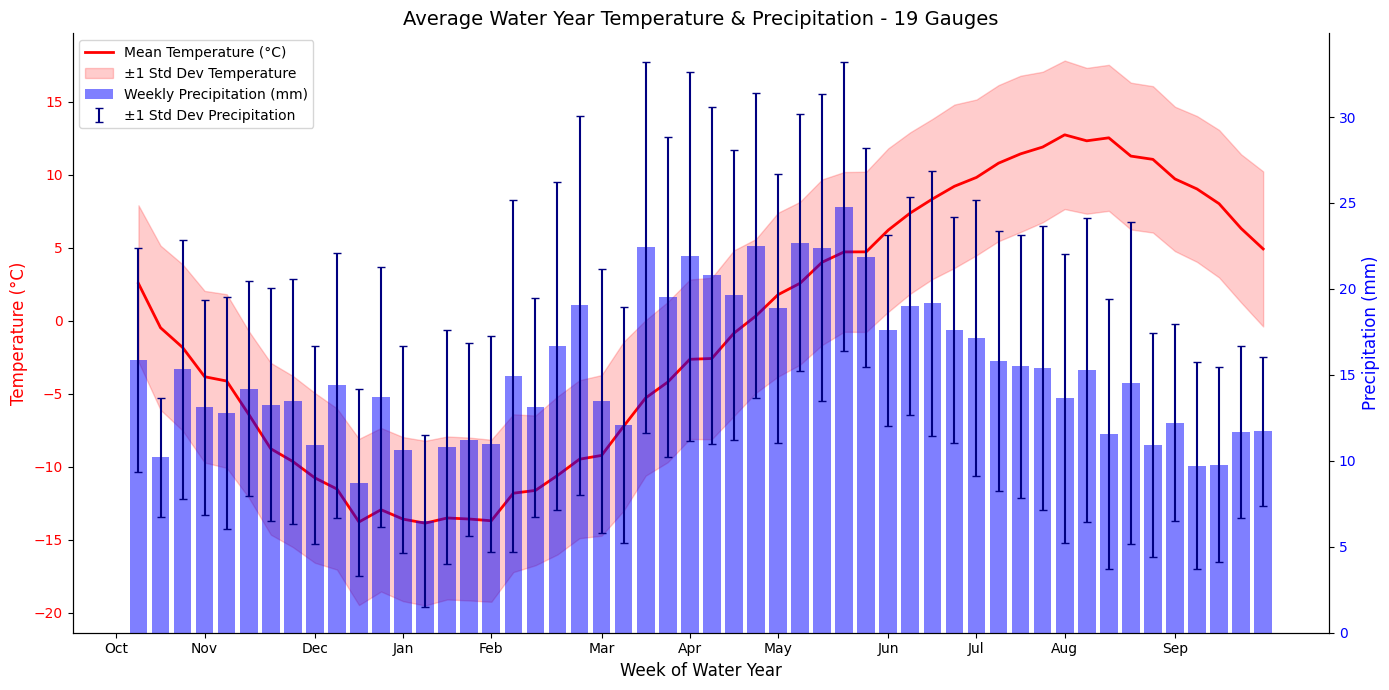

In [8]:
fig, _= plot_water_year_temperature_precipitation(group_data["ca_ts_data"], gauges_in_cluster)

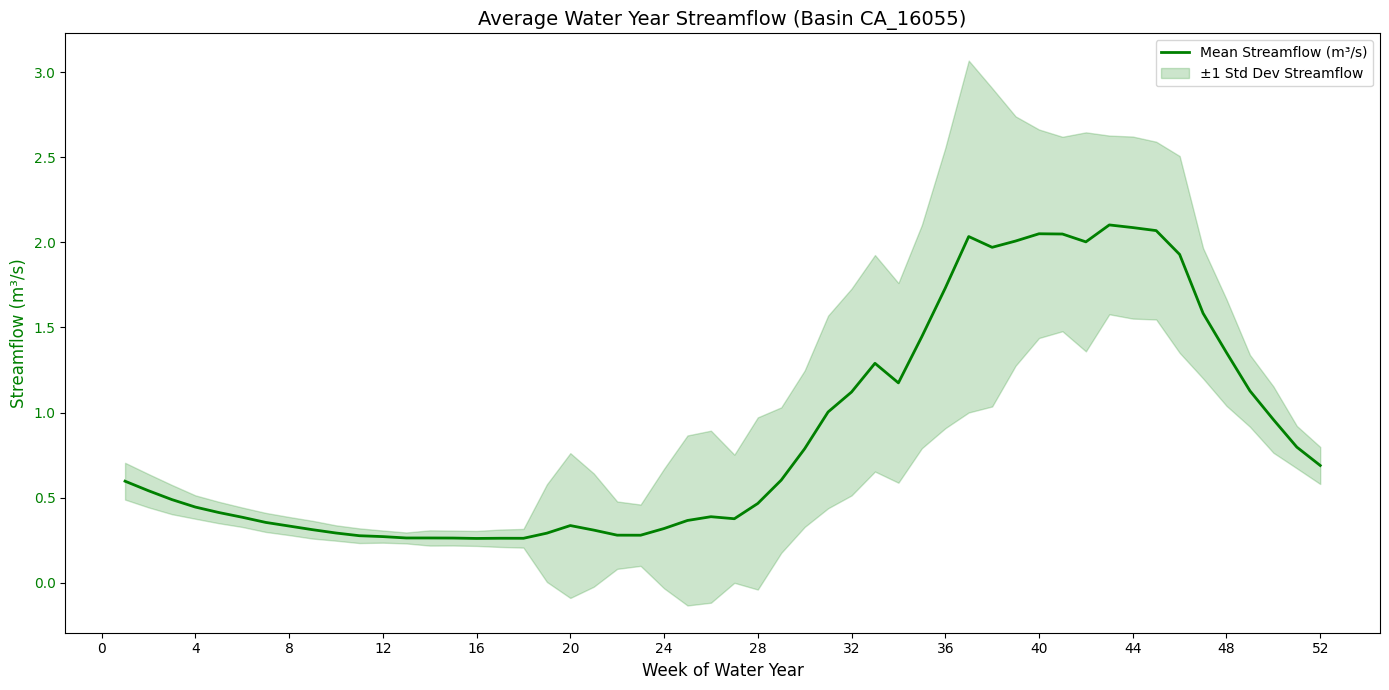

In [10]:
# Add streamflow to the plot
basin_id = gauges_in_cluster[1]  # Can be a single string or list of strings

# Function to compute aggregated statistics across multiple basins
def create_water_year_aggregates(df, basin_ids, basin_id_col, date_col, agg_dict):
    """
    Create water year aggregates for either a single basin or multiple basins.
    
    Args:
        df: DataFrame with time series data
        basin_ids: Single basin ID or list of basin IDs
        basin_id_col: Column name for basin identifier
        date_col: Column name for date
        agg_dict: Dictionary of column names and aggregation functions
    
    Returns:
        DataFrame with weekly aggregated values
    """
    # Convert single basin_id to list for uniform processing
    if isinstance(basin_ids, str):
        basin_ids = [basin_ids]
    
    # Filter data for specified basins
    basin_data = df[df[basin_id_col].isin(basin_ids)].copy()
    
    # Add water year
    basin_data['water_year'] = basin_data[date_col].dt.year.where(
        basin_data[date_col].dt.month < 10, 
        basin_data[date_col].dt.year + 1
    )
    
    # Add day of water year
    basin_data['day_of_water_year'] = basin_data.groupby([basin_id_col, 'water_year'])[date_col].transform(
        lambda x: (x - x.min()).dt.days
    )
    
    # Calculate week of water year (1-52)
    basin_data['week'] = (basin_data['day_of_water_year'] // 7) + 1
    basin_data['week'] = basin_data['week'].clip(upper=52)  # Ensure max week is 52
    
    # Group by week and calculate statistics
    result = basin_data.groupby('week').agg({**agg_dict})
    
    # Calculate standard deviation if we have multiple basins or water years
    for col in agg_dict:
        result[f'{col}_std'] = basin_data.groupby('week')[col].std()
    
    # Reset index for easier plotting
    result = result.reset_index()
    
    return result

# Calculate aggregated statistics
agg_dict = {"streamflow": "mean"}
avg_weekly = create_water_year_aggregates(
    group_data["ca_ts_data"], basin_id, "gauge_id", "date", agg_dict
)

# Create the plot
fig, ax1 = plt.subplots(figsize=(14, 7))
weeks = avg_weekly["week"]
streamflow_mean = avg_weekly["streamflow"]
streamflow_std = avg_weekly.get("streamflow_std", pd.Series([0] * len(weeks))).fillna(0)

# Plot mean streamflow
ax1.plot(
    weeks,
    streamflow_mean,
    color="green",
    label="Mean Streamflow (m³/s)",
    linewidth=2,
)

# Configure plot settings
ax1.set_xlabel("Week of Water Year", fontsize=12)
ax1.set_ylabel("Streamflow (m³/s)", color="green", fontsize=12)
ax1.tick_params(axis="y", labelcolor="green")
ax1.set_xticks(np.arange(0, 53, step=4))

# Add standard deviation band
ax1.fill_between(
    weeks,
    streamflow_mean - streamflow_std,
    streamflow_mean + streamflow_std,
    color="green",
    alpha=0.2,
    label="±1 Std Dev Streamflow",
)

# Add basin information to title
basin_info = f"({len(basin_id)} basins)" if isinstance(basin_id, list) else f"(Basin {basin_id})"
ax1.set_title(f"Average Water Year Streamflow {basin_info}", fontsize=14)
ax1.legend()

plt.tight_layout()
plt.show()




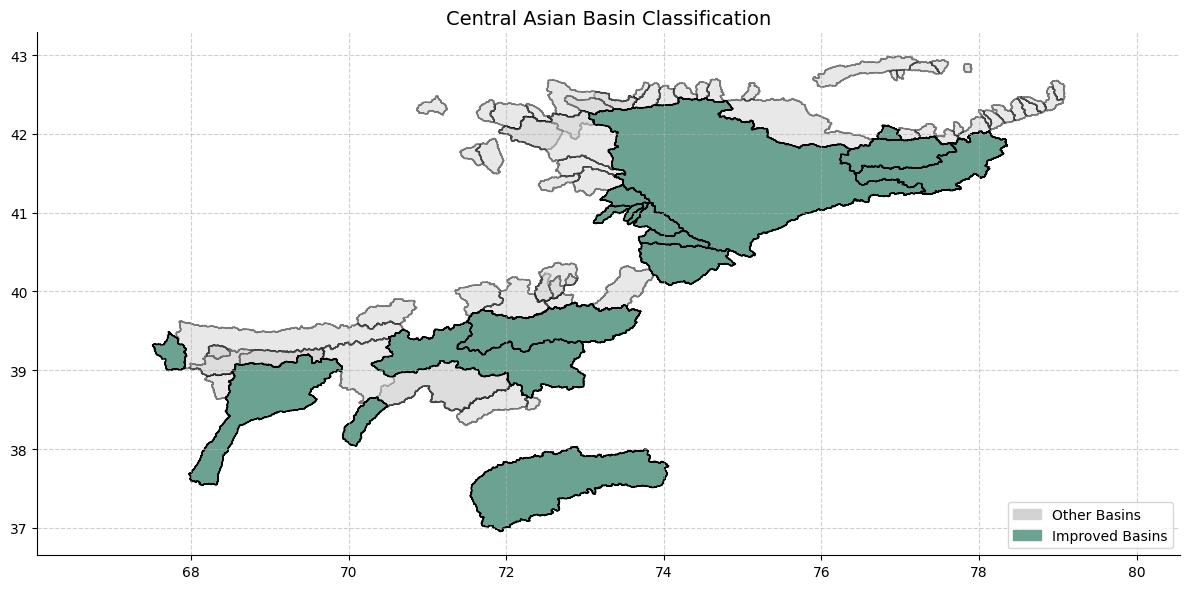

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Load and process the data
path_to_kgz_basins = "/Users/cooper/Desktop/CAMELS-CH/data/CA_raw/basin_outline/kyrgyzstan/HRU_KRG_ML_MODEL_BASINS_1d.shp"
path_to_tjik_basins = "/Users/cooper/Desktop/CAMELS-CH/data/CA_raw/basin_outline/tajikistan/HRU_TAJIK_ML_MODEL_BASINS_1d.shp"

# Load basin geometries and ensure consistent projection
kgz_basins = gpd.read_file(path_to_kgz_basins).to_crs(epsg=4326)
tjik_basins = gpd.read_file(path_to_tjik_basins).to_crs(epsg=4326)

# Create masks for different basin categories
# Make sure the column names match your shapefile attributes
kgz_mask = (
    kgz_basins["CODE"].astype(str).apply(lambda x: f"CA_{x}" in gauges_in_cluster)
)
tjik_mask = (
    tjik_basins["CODE"].astype(str).apply(lambda x: f"CA_{x}" in gauges_in_cluster)
)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot regular basins
kgz_basins[~kgz_mask].plot(ax=ax, color="lightgrey", edgecolor="black", alpha=0.5)
tjik_basins[~tjik_mask].plot(ax=ax, color="lightgrey", edgecolor="black", alpha=0.5)

# Plot improved basins - check if there are any matches before plotting
if kgz_mask.any():
    kgz_basins[kgz_mask].plot(ax=ax, color="#6BA292", edgecolor="black")

if tjik_mask.any():
    tjik_basins[tjik_mask].plot(ax=ax, color="#6BA292", edgecolor="black")

# Manually add legend
legend_patches = [
    mpatches.Patch(color="lightgrey", label="Other Basins"),
    mpatches.Patch(color="#6BA292", label="Improved Basins"),
]

ax.legend(handles=legend_patches, loc="lower right")

# Customize the plot
plt.axis("equal")
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Central Asian Basin Classification", fontsize=14)

# Add contextual information if needed
if not (kgz_mask.any() or tjik_mask.any()):
    plt.figtext(
        0.5,
        0.01,
        "Note: No basins matched the cluster criteria",
        ha="center",
        fontsize=10,
        style="italic",
    )

# Adjust layout to prevent legend cutoff
plt.tight_layout()
sns.despine()

plt.show()

In [12]:
gauges_in_cluster

['CA_15054',
 'CA_16055',
 'CA_16059',
 'CA_16068',
 'CA_16070',
 'CA_16121',
 'CA_16127',
 'CA_16134',
 'CA_16135',
 'CA_16139',
 'CA_16143',
 'CA_16487',
 'CA_17050',
 'CA_17077',
 'CA_17082',
 'CA_17100',
 'CA_17137',
 'CA_17344',
 'CA_17462']